# 示例策略13: 经典网格交易策略

本策略是一个经典的网格交易策略
根据交易标的过去300天的波动范围设置天单和地单，并设置好网格的宽度以及定价交易单
当股价产生波动的时候执行定价买卖操作

根据网格交易策略，每成交一单后，即会在相邻的网格再次挂单等待交易

交易回测的标的是：

交易回测区间是：


In [1]:
import qteasy as qt
import pandas as pd
import numpy as np

In [13]:
class GridTrade(qt.RuleIterator):
    
    def realize(self, h, r=None, t=None, pars=None):
        
        # 忽略临时策略参数，读取当前保存的策略参数
        grid_size, trade_batch, base_grid = self.pars

        # 读取最新价格
        price = h[-1, 0]  # 最近一个K线周期的close价格
        
        # 计算当前价格与当前网格的偏离程度，判断是否产生交易信号
        if base_grid <= 0.01:
            # 基准网格尚未设置，此时为首次运行，首次买入1000股并设置基准网格为当前价格（精确到0.1元）
            result = 1510
            base_grid = np.round(price / 0.1) * 0.1
#             print(f'first-off trade: buy in 1000 @ {price} and set base_grid = {base_grid}')
        elif price - base_grid > grid_size:
            # 触及卖出网格线，产生卖出信号
            result = - trade_batch  # 交易信号等于交易数量，必须使用VS信号类型
            # 重新计算基准网格
            base_grid += grid_size 
#             print(f'sell out 200 @ {price} and set base_grid = {base_grid}')
        elif base_grid - price > grid_size:
            # 触及买入网格线，产生买入信号
            result = trade_batch + 10
            # 重新计算基准网格
            base_grid -= grid_size
#             print(f'buy in 200 @ {price} and set base_grid = {base_grid}')
        else:
            result = 0
        
        # 使用新的基准网格更新交易参数
        self.pars = grid_size, trade_batch, base_grid
        
        return result
            


     |                                  |
     |       BACK TESTING RESULT        |
     |                                  |

qteasy running mode: 1 - History back testing
time consumption for operate signal creation: 0.0 ms
time consumption for operation back looping:  839.9 ms

investment starts on      2023-01-03 09:30:00
ends on                   2023-02-28 15:00:00
Total looped periods:     0.2 years.

-------------operation summary:------------
Only non-empty shares are displayed, call 
"loop_result["oper_count"]" for complete operation summary

          Sell Cnt Buy Cnt Total Long pct Short pct Empty pct
000651.SZ    13       8      21   93.0%      0.0%      7.0%   

Total operation fee:     ¥       63.36
total investment amount: ¥  100,000.00
final value:              ¥  104,070.64
Total return:                      inf% 
Avg Yearly return:                 inf%
Skewness:                          3.79
Kurtosis:                         52.19
Benchmark return:                 9

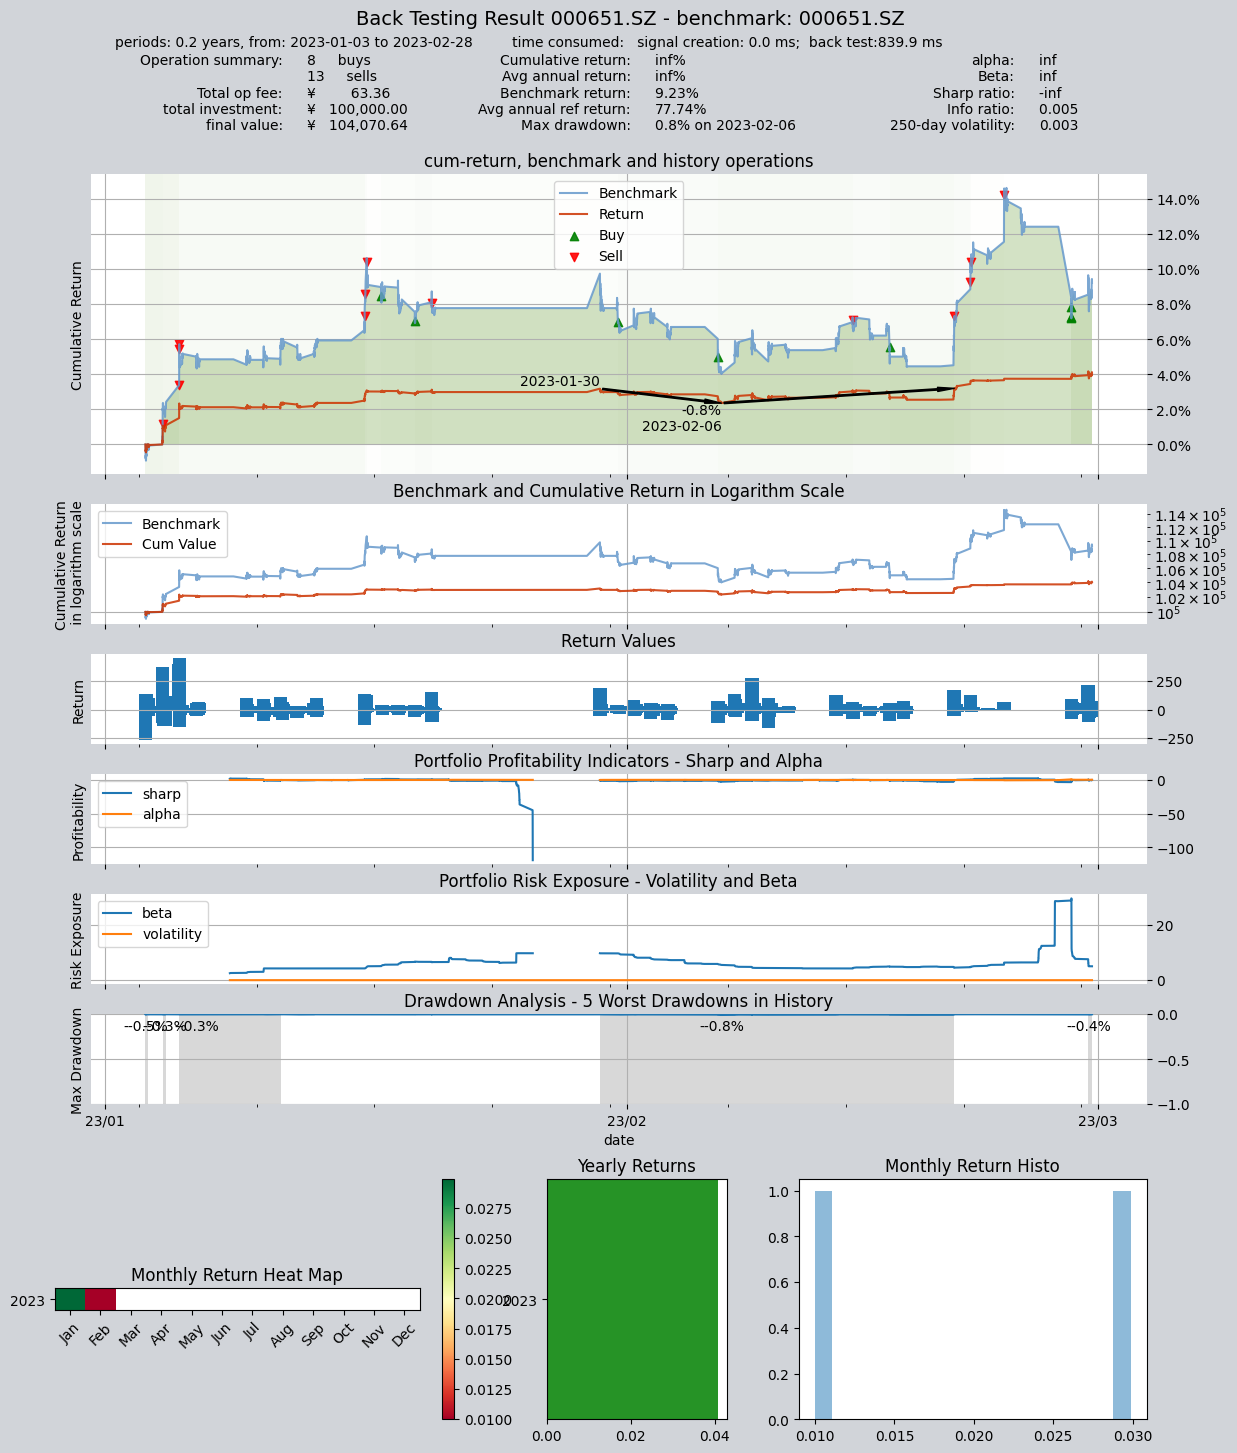

In [14]:
alpha = GridTrade(pars=(0.5, 200, 0.0),  # 当基准网格为0时，代表首次运行，此时买入1000股，并设置当前价为基准网格
                   par_count=3,
                   par_types=['float', 'int', 'float'],
                   par_range=[(0.2, 2), (100, 300), (0, 40)],
                   name='GridTrade',
                   description='网格交易策略，当前股票价格波动幅度超过网格尺寸时，产生卖出或买入交易信号，并更新网格',
                   strategy_data_types='close',
                   strategy_run_freq='5min',
                   data_freq='5min',
                   window_length=20,
                  ) 

op = qt.Operator(alpha, signal_type='VS')  # 交易信号等于交易数量，必须使用VS信号类型
op.op_type = 'stepwise'  # 需要动态更新策略参数，必须使用'stepwise'交易类型
op.set_parameter(0, (0.5, 200, 0.0))
op.run(mode=1,
       asset_type='E',
       asset_pool='000651.SZ',
       benchmark_asset='000651.SZ',
       benchmark_asset_type='E',
       benchmark_dtype='close',
       trade_batch_size=100,
       sell_batch_size=1,
       trade_log=True,
       invest_start='20230101',
       invest_end='20230301',
       backtest_price_adj='none',
      )
print()